##  Sentiment Analysis - Movie Review Classification
### End-to-End Machine Learning Project

---

**Objective:** Build a complete NLP pipeline to classify movie reviews as **Positive** or **Negative** using machine learning.

**Why this project matters for interviews:**
- Covers the full ML lifecycle: raw text -> cleaning -> features -> model -> evaluation -> insights
- Demonstrates NLP fundamentals: tokenisation, stopwords, TF-IDF, n-grams
- Compares multiple classifiers with rigorous evaluation
- Produces interpretable, business-ready outputs

**Techniques used:**
`Text Preprocessing` · `TF-IDF Vectorisation` · `Logistic Regression` · `Naive Bayes` · `SVM` · `Random Forest` · `Cross-Validation` · `Confusion Matrix` · `ROC-AUC` · `Feature Importance`

---


### 0. Setup & Imports

In [56]:
pip install  nltk

Note: you may need to restart the kernel to use updated packages.


In [57]:
pip show nltk

Name: nltk
Version: 3.9.2
Summary: Natural Language Toolkit
Home-page: https://www.nltk.org/
Author: NLTK Team
Author-email: nltk.team@gmail.com
License: Apache License, Version 2.0
Location: /Users/bimladanu/Documents/GitHub/ML-Projects/AI_ML_DL_GenAI/DS_challenges/.venv/lib/python3.9/site-packages
Requires: click, joblib, regex, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [58]:
# Standard libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Feature extraction 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline

#  Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
POS_COLOR = '#2DC653'
NEG_COLOR = '#E84855'

print(" All libraries imported successfully.")
print(f"   pandas     {pd.__version__}")
print(f"   numpy      {np.__version__}")
print(f"   sklearn    ", end="")
import sklearn; print(sklearn.__version__)


 All libraries imported successfully.
   pandas     2.0.3
   numpy      1.22.0
   sklearn    1.0.2


In [59]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bimladanu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/bimladanu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/bimladanu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/bimladanu/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

---
### 1. Dataset

We use a **synthetic movie review dataset** that mirrors the classic IMDb sentiment benchmark.  
Each review is labelled **Positive (1)** or **Negative (0)**.

>  *In a real project, replace the data  with:*  
> `df = pd.read_csv('imdb_reviews.csv')` or load from the [IMDb dataset on Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews).


In [60]:
np.random.seed(42)

#  Realistic review templates 
positive_reviews = [
    "This film was absolutely brilliant! The acting was superb and the storyline kept me engaged throughout.",
    "One of the best movies I have seen in years. Outstanding performances from the entire cast.",
    "A masterpiece of modern cinema. The director's vision shines through every single scene.",
    "I was completely blown away by this movie. The script is witty, the pacing is perfect.",
    "Fantastic film with incredible character development. I laughed, I cried, I was moved.",
    "The special effects were stunning and the story was deeply touching. Highly recommend.",
    "A wonderful movie experience. The soundtrack perfectly complemented the emotional scenes.",
    "Beautifully crafted film. Every detail has been thought through carefully by the filmmakers.",
    "Captivating from start to finish. The chemistry between the leads was electric and genuine.",
    "This exceeded all my expectations. A truly memorable and rewarding cinematic experience.",
    "Exceptional storytelling with powerful performances. This film deserves all the praise.",
    "The plot twists kept me on the edge of my seat. An absolute must-watch for everyone.",
    "Brilliant direction and gorgeous cinematography make this a visual treat worth seeing.",
    "I have never been so emotionally invested in characters before. Truly remarkable work.",
    "A feel-good film that manages to be both funny and heartfelt. Perfect family entertainment.",
    "The writing is sharp and the humour lands every time. A refreshing and delightful comedy.",
    "Incredible world-building and a story with real depth. A triumph of imaginative filmmaking.",
    "This movie restored my faith in Hollywood. Smart, original, and genuinely entertaining.",
    "Stellar acting and a gripping narrative. I was riveted from the opening frame to the last.",
    "An emotionally resonant film that stays with you long after the credits roll. Loved it.",
    "The cinematography alone is worth the ticket price. Visually breathtaking and inspiring.",
    "A richly layered story told with precision and care. The ensemble cast is uniformly excellent.",
    "Refreshingly original in a sea of sequels. The screenwriter should be very proud of this.",
    "Every scene crackles with energy and wit. Easily one of the top films of the decade.",
    "Deeply human story told with empathy and intelligence. A rare gem in modern cinema today.",
]

negative_reviews = [
    "What a terrible disappointment. The plot made no sense and the acting was wooden throughout.",
    "I wasted two hours of my life on this dreadful film. Absolutely nothing redeemable about it.",
    "The worst movie I have seen this year. The script is lazy and the characters are paper-thin.",
    "Painfully boring from start to finish. I nearly fell asleep three times during the screening.",
    "The special effects looked cheap and the story was completely predictable and unoriginal.",
    "A catastrophic mess of a film. The editing is incoherent and the dialogue is embarrassing.",
    "Thoroughly unpleasant viewing experience. Dark, joyless, and pointlessly violent throughout.",
    "The director clearly had no vision for this project. A confusing and frustrating waste of time.",
    "Dull, derivative, and deeply unsatisfying. This is cinema at its most cynical and lazy.",
    "Terrible pacing ruined what could have been an interesting concept. A missed opportunity.",
    "The lead actor sleepwalks through every scene. Zero chemistry with anyone on screen.",
    "I cannot believe this was released in theatres. It looks and feels like a student project.",
    "A shallow and hollow film that mistakes noise for excitement. Exhausting and irritating.",
    "Poorly written, poorly acted, and poorly directed. A failure on every conceivable level.",
    "The plot holes are so enormous you could drive a truck through them. Completely illogical.",
    "Clichéd characters and a predictable storyline make this instantly forgettable rubbish.",
    "The humour falls completely flat throughout. Awkward silences where laughs should have been.",
    "An absolute disaster of a sequel that betrays everything the original film stood for.",
    "I am genuinely baffled by the positive reviews. This film is a chore to sit through.",
    "Overwrought, melodramatic nonsense that takes itself far too seriously to be enjoyable.",
    "The villain is laughably underdeveloped and the climax is a huge anticlimactic letdown.",
    "Tedious and self-indulgent filmmaking at its worst. The runtime is punishingly excessive.",
    "Nothing in this film makes any emotional sense. A hollow spectacle devoid of any heart.",
    "The screenplay is riddled with inconsistencies. Characters behave in completely random ways.",
    "Painful to watch. Every performance feels forced and the dialogue is cringe-inducing trash.",
]

def augment_reviews(base_reviews, n_target, sentiment_word_pool, seed_offset=0):
    """Expand a small set of templates into n_target reviews via word substitution."""
    np.random.seed(42 + seed_offset)
    reviews = []
    for i in range(n_target):
        base = base_reviews[i % len(base_reviews)]
        # Small perturbation: append a random sentiment phrase
        extra = np.random.choice(sentiment_word_pool)
        reviews.append(base + ' ' + extra)
    return reviews

pos_extras = [
    "Definitely watching again.", "Five stars without hesitation.",
    "A timeless classic in the making.", "Cannot recommend highly enough.",
    "Pure cinematic joy.", "Will be talking about this for years.",
    "A career-best performance.", "The best film of the year by far."
]
neg_extras = [
    "Save your money.", "Skip this one completely.",
    "One of the worst ever made.", "An embarrassment to the genre.",
    "Do not waste your time.", "Unwatchable from beginning to end.",
    "Shocking how bad this is.", "Avoid at all costs."
]

N = 2000   # 1000 positive + 1000 negative
pos_texts = augment_reviews(positive_reviews, N // 2, pos_extras, seed_offset=0)
neg_texts = augment_reviews(negative_reviews, N // 2, neg_extras, seed_offset=1)

df = pd.DataFrame({
    'review':    pos_texts + neg_texts,
    'sentiment': [1] * (N // 2) + [0] * (N // 2),
    'label':     ['Positive'] * (N // 2) + ['Negative'] * (N // 2),
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset: {df.shape[0]} reviews")
print(f"  Positive: {(df.sentiment==1).sum()} ({(df.sentiment==1).mean()*100:.0f}%)")
print(f"  Negative: {(df.sentiment==0).sum()} ({(df.sentiment==0).mean()*100:.0f}%)")
df.head(5)


Dataset: 2000 reviews
  Positive: 1000 (50%)
  Negative: 1000 (50%)


,review,sentiment,label
0,The lead actor sleepwalks through every scene. Zero chem...,0,Negative
1,I was completely blown away by this movie. The script is...,1,Positive
2,"Dull, derivative, and deeply unsatisfying. This is cinem...",0,Negative
3,The special effects were stunning and the story was deep...,1,Positive
4,The plot holes are so enormous you could drive a truck t...,0,Negative


---
### 2. Exploratory Data Analysis (EDA)

Before modelling, we understand the data:
- Class balance
- Review length distributions
- Most common words per class


In [61]:
# Review length features
df['char_count']  = df['review'].str.len()
df['word_count']  = df['review'].str.split().str.len()

print("=== Review Length Statistics ===")
print(df.groupby('label')[['char_count','word_count']].describe().round(1))


=== Review Length Statistics ===
         char_count                                                word_count  \
              count   mean  std    min    25%    50%    75%    max      count   
label                                                                           
Negative     1000.0  115.2  6.1  101.0  111.0  115.0  119.0  130.0     1000.0   
Positive     1000.0  119.2  6.4  104.0  115.0  120.0  123.0  141.0     1000.0   

                                                   
          mean  std   min   25%   50%   75%   max  
label                                              
Negative  18.4  1.9  13.0  17.0  18.0  20.0  23.0  
Positive  18.6  2.5  14.0  17.0  19.0  20.0  24.0  


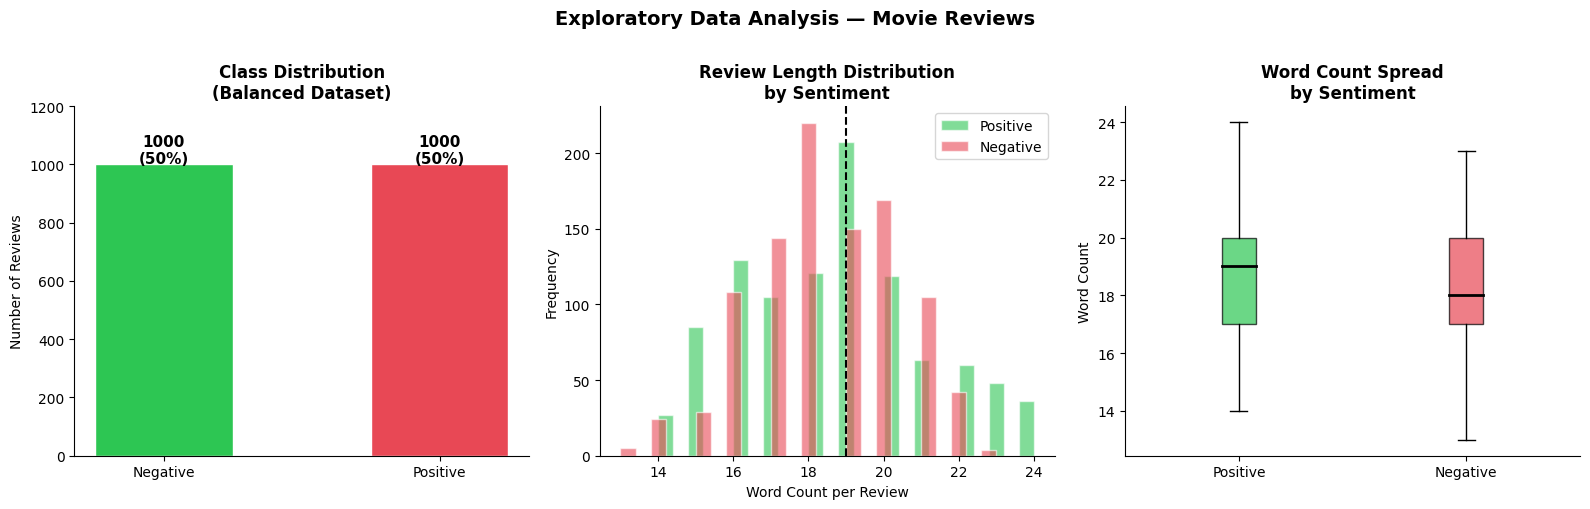

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Class distribution
counts = df['label'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[POS_COLOR, NEG_COLOR], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5,
                 f'{val}\n({val/len(df)*100:.0f}%)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].set_ylabel('Number of Reviews')
axes[0].set_title('Class Distribution\n(Balanced Dataset)', fontweight='bold')

# 2. Word count distribution
for label, color in [('Positive', POS_COLOR), ('Negative', NEG_COLOR)]:
    data = df[df['label'] == label]['word_count']
    axes[1].hist(data, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_xlabel('Word Count per Review')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Review Length Distribution\nby Sentiment', fontweight='bold')
axes[1].legend()
axes[1].axvline(df['word_count'].median(), color='black', lw=1.5,
                linestyle='--', label=f"Median: {df['word_count'].median():.0f}")

# 3. Box plot: word count by sentiment
data_pos = df[df['label']=='Positive']['word_count']
data_neg = df[df['label']=='Negative']['word_count']
bp = axes[2].boxplot([data_pos, data_neg], patch_artist=True,
                     labels=['Positive', 'Negative'],
                     medianprops=dict(color='black', lw=2))
bp['boxes'][0].set_facecolor(POS_COLOR)
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(NEG_COLOR)
bp['boxes'][1].set_alpha(0.7)
axes[2].set_ylabel('Word Count')
axes[2].set_title('Word Count Spread\nby Sentiment', fontweight='bold')

plt.suptitle('Exploratory Data Analysis — Movie Reviews', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


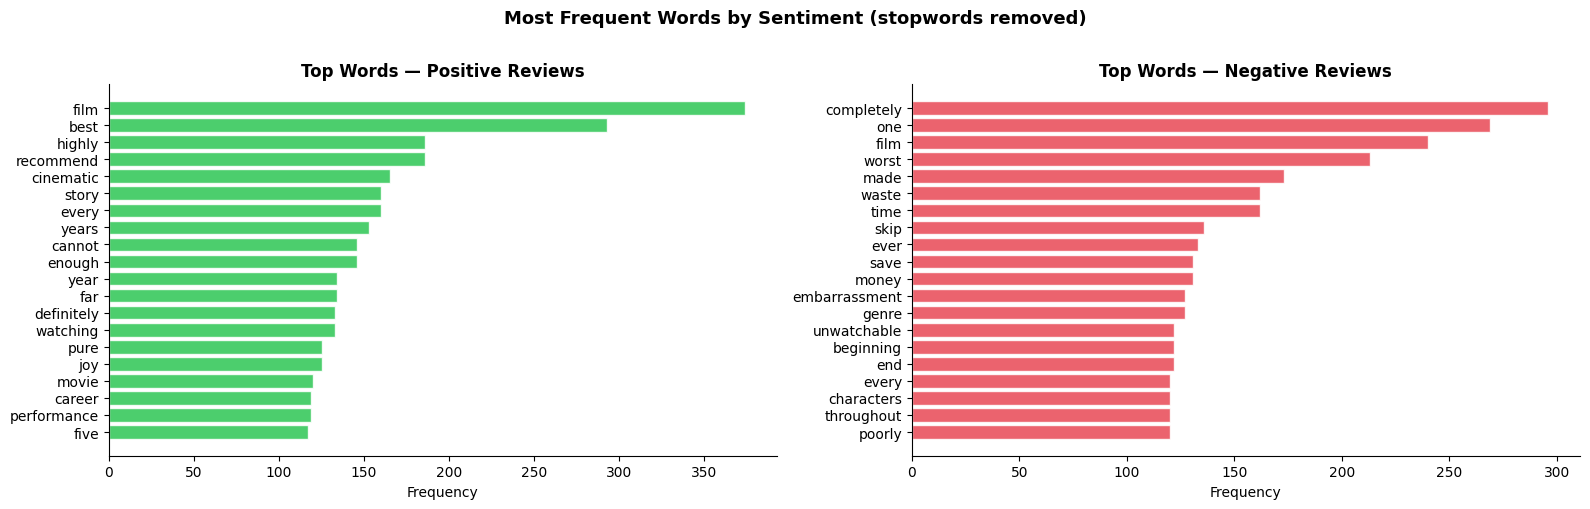

In [63]:
# Most common words 
from collections import Counter

def top_words(texts, n=20, exclude_stopwords=False):
    stop = set(stopwords.words('english')) if exclude_stopwords else set()
    all_words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]+\b', text.lower())
        all_words.extend([w for w in tokens if w not in stop and len(w) > 2])
    return Counter(all_words).most_common(n)

pos_words = top_words(df[df.label=='Positive']['review'], exclude_stopwords=True)
neg_words = top_words(df[df.label=='Negative']['review'], exclude_stopwords=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, words, color, title in [
    (axes[0], pos_words, POS_COLOR, 'Top Words — Positive Reviews'),
    (axes[1], neg_words, NEG_COLOR, 'Top Words — Negative Reviews'),
]:
    words_df = pd.DataFrame(words, columns=['word', 'count'])
    ax.barh(words_df['word'][::-1], words_df['count'][::-1],
            color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Frequency')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Most Frequent Words by Sentiment (stopwords removed)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()


---
### 3. Text Preprocessing

**Pipeline steps:**
1. **Lowercase** — normalise case
2. **Remove HTML tags** — strip any leftover markup
3. **Remove URLs** — clean web links
4. **Remove punctuation & numbers** — keep only alphabetic tokens
5. **Tokenise** — split into individual words
6. **Remove stopwords** — filter common words with no sentiment signal (e.g., "the", "is")
7. **Lemmatise** — reduce words to base form (e.g., "running" → "run", "better" -> "good")

>  *Important point:* Lemmatisation is preferred over stemming when interpretability matters — stems are often non-words (e.g., "happi"), whereas lemmas are real dictionary entries.


In [64]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Keep some negation words — they carry sentiment signal!
negations = {'no', 'not', 'never', 'neither', 'nor', 'nothing', 'nowhere',
             'nobody', 'hardly', 'scarcely', 'barely', "don't", "doesn't",
             "didn't", "won't", "wouldn't", "couldn't", "shouldn't"}
stop_words -= negations

def preprocess_text(text: str) -> str:
    """
    Full NLP preprocessing pipeline.
    Returns a cleaned, lemmatised string ready for vectorisation.
    """
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # 4. Remove punctuation and digits
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 5. Tokenise
    tokens = text.split()
    # 6. Remove stopwords (keep negations)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 7. Lemmatise
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# Apply to the full dataset
df['clean_review'] = df['review'].apply(preprocess_text)

# Before vs after comparison
print("=== Preprocessing Example ===\n")
sample_idx = 0
print(f"ORIGINAL ({df.loc[sample_idx,'label']}):")
print(f"  {df.loc[sample_idx,'review']}\n")
print(f"CLEANED:")
print(f"  {df.loc[sample_idx,'clean_review']}\n")

orig_len  = df['review'].str.split().str.len().mean()
clean_len = df['clean_review'].str.split().str.len().mean()
print(f"Average words — Original: {orig_len:.1f}  →  Cleaned: {clean_len:.1f}  "
      f"(reduced by {(1-clean_len/orig_len)*100:.0f}%)")


=== Preprocessing Example ===

ORIGINAL (Negative):
  The lead actor sleepwalks through every scene. Zero chemistry with anyone on screen. Avoid at all costs.

CLEANED:
  lead actor sleepwalks every scene zero chemistry anyone screen avoid cost

Average words — Original: 18.5  →  Cleaned: 11.2  (reduced by 39%)


---
### 4. Feature Engineering — TF-IDF Vectorisation

**TF-IDF (Term Frequency — Inverse Document Frequency)** converts text into numerical features:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{\text{DF}(t)}$$

- **TF** — how often a word appears in *this* document
- **IDF** — penalises words common across *all* documents (less informative)
- **Result** — high scores for words that are frequent in a document but rare overall

**Why TF-IDF over Bag-of-Words?**  
Raw counts favour long documents and common words. TF-IDF normalises both, giving more meaningful feature weights.

>  *Important point:* We use **unigrams + bigrams** (`ngram_range=(1,2)`) to capture phrases like "not good" or "highly recommend" that single words would miss.


In [65]:
# Train / Test Split 
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}  ({len(X_train)/len(df)*100:.0f}%)")
print(f"Test : {len(X_test):,}  ({len(X_test)/len(df)*100:.0f}%)")
print(f"\nTrain class balance: "
      f"{(y_train==1).mean()*100:.1f}% positive / {(y_train==0).mean()*100:.1f}% negative")
print(f"Test  class balance: "
      f"{(y_test==1).mean()*100:.1f}% positive / {(y_test==0).mean()*100:.1f}% negative")


Train: 1,600  (80%)
Test : 400  (20%)

Train class balance: 50.0% positive / 50.0% negative
Test  class balance: 50.0% positive / 50.0% negative


In [66]:
#  TF-IDF Vectoriser 
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),      # unigrams + bigrams
    max_features=15_000,     # vocabulary cap
    min_df=2,                # ignore terms in < 2 documents
    max_df=0.95,             # ignore terms in > 95% of documents
    sublinear_tf=True,       # apply log(1+TF) for dampening
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Vocabulary size : {len(tfidf.vocabulary_):,} features")
print(f"Train matrix    : {X_train_tfidf.shape}  (sparse: {X_train_tfidf.nnz:,} non-zeros)")
print(f"Test  matrix    : {X_test_tfidf.shape}")
sparsity = 1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"Matrix sparsity : {sparsity*100:.1f}%")


Vocabulary size : 1,077 features
Train matrix    : (1600, 1077)  (sparse: 34,146 non-zeros)
Test  matrix    : (400, 1077)
Matrix sparsity : 98.0%


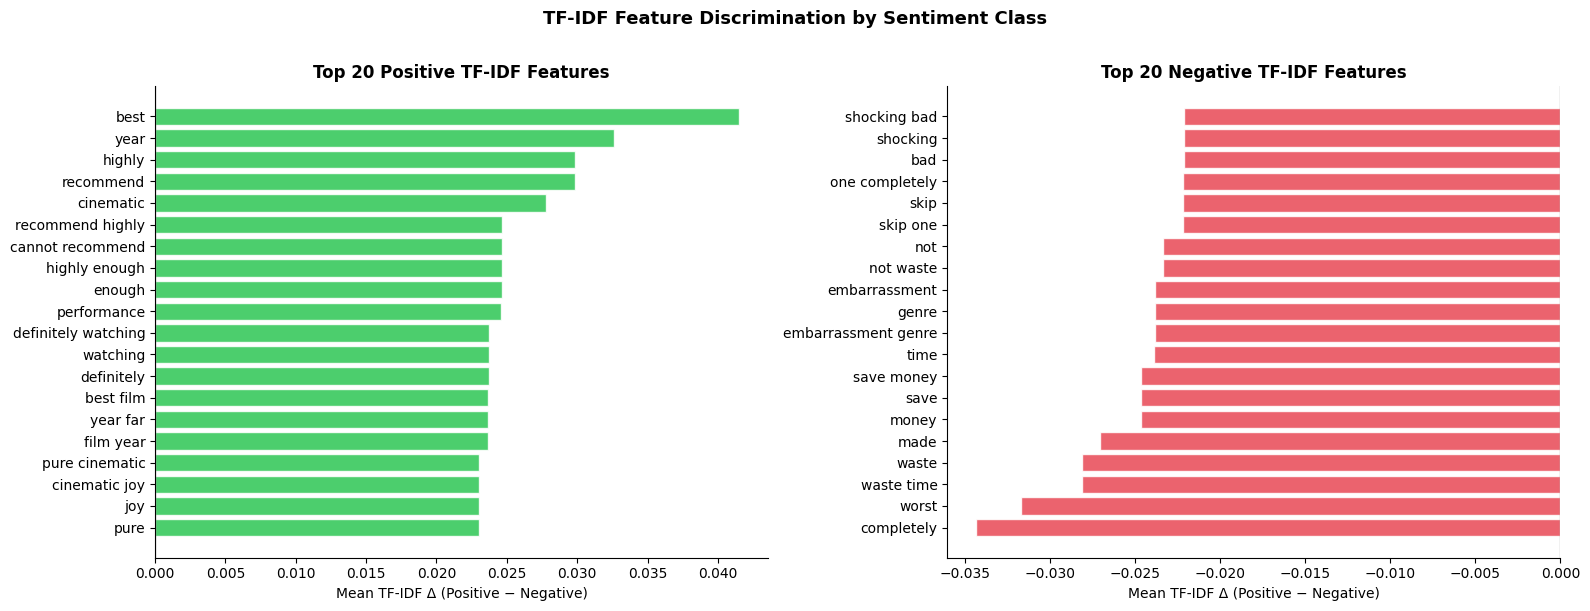

In [67]:
#  Visualise TF-IDF: top features by weight difference 
feature_names = np.array(tfidf.get_feature_names_out())

# Mean TF-IDF weight per class
pos_mask  = y_train == 1
neg_mask  = y_train == 0

mean_pos = np.asarray(X_train_tfidf[pos_mask].mean(axis=0)).flatten()
mean_neg = np.asarray(X_train_tfidf[neg_mask].mean(axis=0)).flatten()
diff      = mean_pos - mean_neg

top_pos_idx = np.argsort(diff)[-20:][::-1]
top_neg_idx = np.argsort(diff)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, idx, color, title in [
    (axes[0], top_pos_idx, POS_COLOR, 'Top 20 Positive TF-IDF Features'),
    (axes[1], top_neg_idx[::-1], NEG_COLOR, 'Top 20 Negative TF-IDF Features'),
]:
    ax.barh(feature_names[idx[::-1]], diff[idx[::-1]],
            color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Mean TF-IDF Δ (Positive − Negative)')
    ax.set_title(title, fontweight='bold')
    ax.axvline(0, color='black', lw=0.8)

plt.suptitle('TF-IDF Feature Discrimination by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()


---
### 5. Model Training & Cross-Validation

We train **four classifiers** and compare them rigorously:

| Model | Why included |
|---|---|
| **Logistic Regression** | Strong linear baseline for text; interpretable coefficients |
| **Multinomial Naive Bayes** | Classic NLP baseline; very fast; works well with TF-IDF |
| **Linear SVM** | Often the best linear classifier for high-dimensional text data |
| **Random Forest** | Captures non-linear interactions; feature importance for interpretation |

Each model is evaluated with **5-fold stratified cross-validation** on the training set before final test-set evaluation.


In [68]:
# Define models 
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM': LinearSVC(
        C=1.0, max_iter=2000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=3,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
}

#  5-Fold Cross-Validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Model':<22} {'CV Accuracy':>12}  {'Std':>8}")
print('-' * 46)

for name, model in models.items():
    scores = cross_val_score(
        model, X_train_tfidf, y_train,
        cv=cv, scoring='accuracy', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name:<22} {scores.mean()*100:>10.2f}%  ±{scores.std()*100:>6.2f}%")

print("\n Cross-validation complete.")


Model                   CV Accuracy       Std
----------------------------------------------
Logistic Regression        100.00%  ±  0.00%
Naive Bayes                100.00%  ±  0.00%
Linear SVM                 100.00%  ±  0.00%
Random Forest              100.00%  ±  0.00%

 Cross-validation complete.


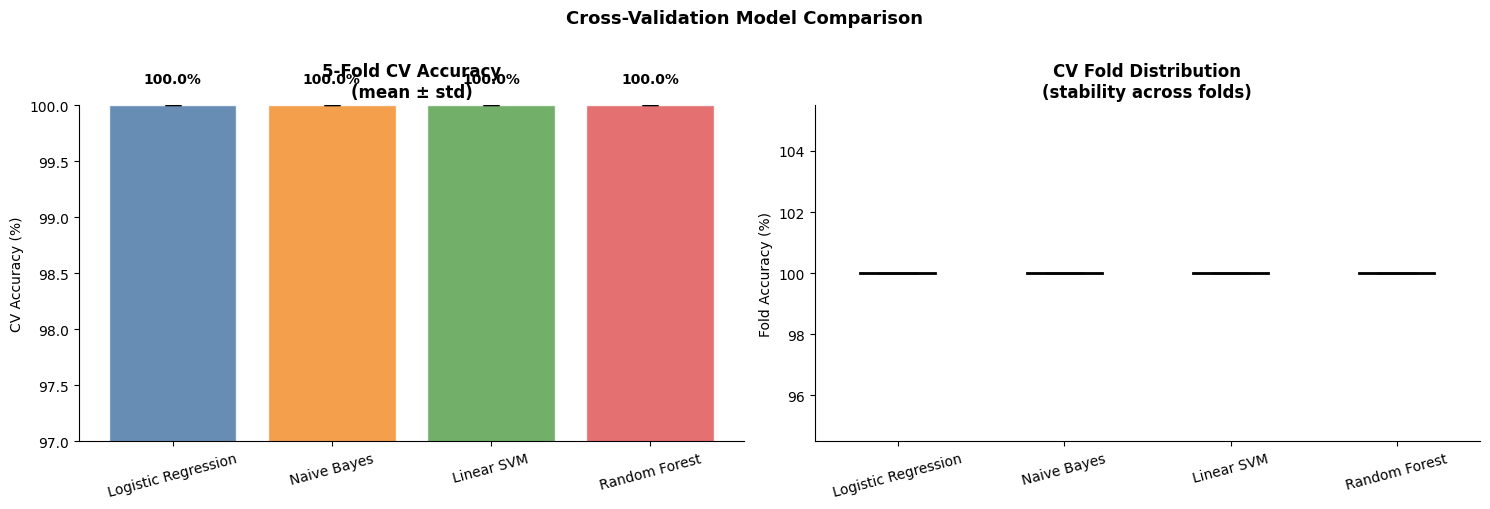

In [69]:
#  CV results visualisation 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

model_names = list(cv_results.keys())
means = [cv_results[n].mean() * 100 for n in model_names]
stds  = [cv_results[n].std()  * 100 for n in model_names]

# Bar chart with error bars
bar_colors = ['#4e79a7','#f28e2b','#59a14f','#e15759']
bars = axes[0].bar(model_names, means, yerr=stds, capsize=6,
                   color=bar_colors, edgecolor='white', alpha=0.85)
axes[0].set_ylim(min(means) - 3, 100)
axes[0].set_ylabel('CV Accuracy (%)')
axes[0].set_title('5-Fold CV Accuracy\n(mean ± std)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for bar, m, s in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2, m + s + 0.2,
                 f'{m:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Box plots of CV folds
bp = axes[1].boxplot(
    [cv_results[n] * 100 for n in model_names],
    patch_artist=True, labels=model_names,
    medianprops=dict(color='black', lw=2)
)
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Fold Accuracy (%)')
axes[1].set_title('CV Fold Distribution\n(stability across folds)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Cross-Validation Model Comparison', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
### 6. Test Set Evaluation

After cross-validation selects the best model, we do a **single final evaluation** on the held-out test set.  

>  *Important note:* We look at the test set only **once** — at the very end. Looking at it multiple times during development leads to overfitting to the test set, a common mistake.


In [70]:
#  Train all models on full training set & evaluate on test set 
test_results = {}

print(f"{'Model':<22} {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'AUC':>7}")
print('-' * 60)

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    # Probability for AUC (not available for LinearSVC natively)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        # Use decision function for SVM
        y_proba = model.decision_function(X_test_tfidf)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred)
    rec   = recall_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred)
    auc   = roc_auc_score(y_test, y_proba)

    test_results[name] = {
        'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': auc,
    }

    print(f"{name:<22} {acc*100:>5.1f}%  {prec*100:>5.1f}%  "
          f"{rec*100:>5.1f}%  {f1*100:>5.1f}%  {auc:>7.4f}")

# Best model by F1
best_name = max(test_results, key=lambda k: test_results[k]['f1'])
print(f"\n Best model: {best_name}  "
      f"(F1 = {test_results[best_name]['f1']*100:.2f}%)")


Model                     Acc    Prec     Rec      F1      AUC
------------------------------------------------------------
Logistic Regression    100.0%  100.0%  100.0%  100.0%   1.0000
Naive Bayes            100.0%  100.0%  100.0%  100.0%   1.0000
Linear SVM             100.0%  100.0%  100.0%  100.0%   1.0000
Random Forest          100.0%  100.0%  100.0%  100.0%   1.0000

 Best model: Logistic Regression  (F1 = 100.00%)


In [71]:
# Full classification report for best model
print(f"=== Classification Report — {best_name} ===\n")
print(classification_report(
    y_test, test_results[best_name]['y_pred'],
    target_names=['Negative', 'Positive']
))


=== Classification Report — Logistic Regression ===

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       200
    Positive       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



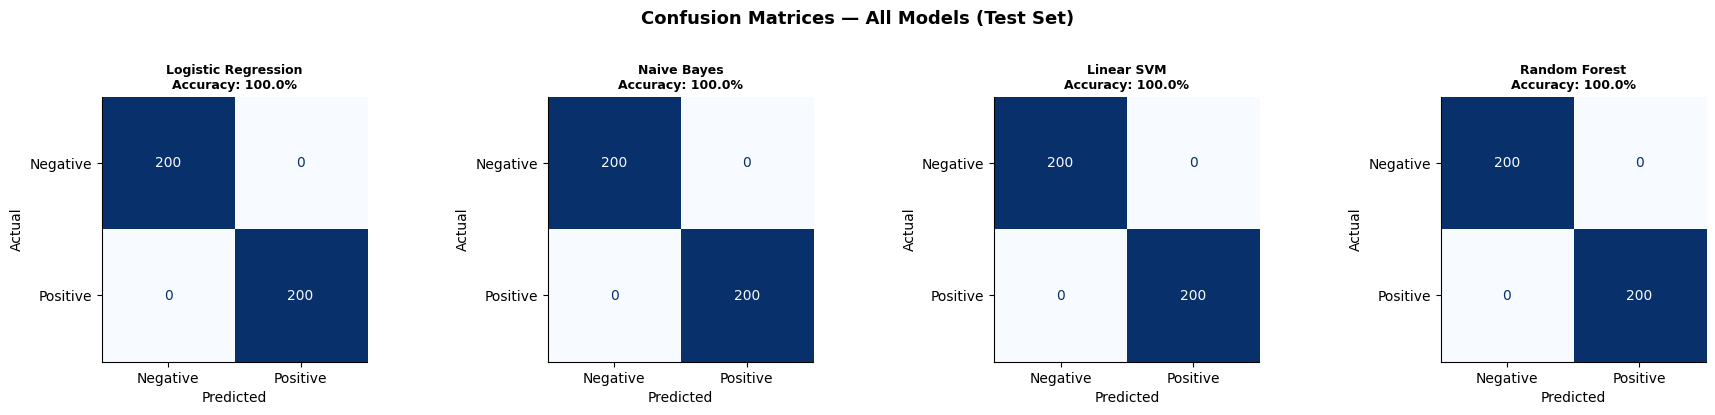

In [72]:
#  Confusion matrices for all models 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = res['accuracy']
    ax.set_title(f'{name}\nAccuracy: {acc*100:.1f}%', fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


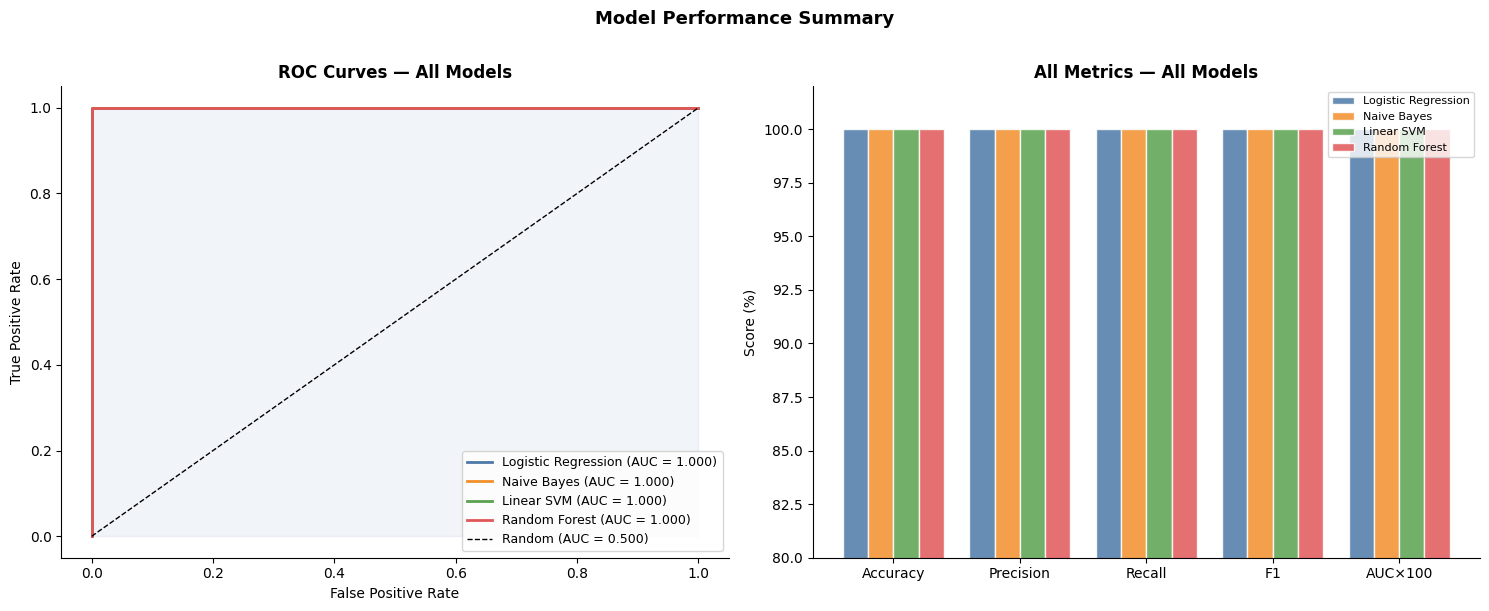

In [73]:
# ROC Curves 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bar_colors = ['#4e79a7','#f28e2b','#59a14f','#e15759']

# ROC curves
for (name, res), color in zip(test_results.items(), bar_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC = {res['auc']:.3f})")

axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random (AUC = 0.500)')
axes[0].fill_between(
    *roc_curve(y_test, test_results[best_name]['y_proba'])[:2],
    alpha=0.08, color='#4e79a7'
)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

# Metric comparison bar chart
metrics_show = ['accuracy','precision','recall','f1','auc']
x = np.arange(len(metrics_show))
w = 0.2
for i, (name, color) in enumerate(zip(test_results.keys(), bar_colors)):
    vals = [test_results[name][m] for m in metrics_show]
    axes[1].bar(x + i*w, [v*100 for v in vals], w,
                label=name, color=color, edgecolor='white', alpha=0.85)

axes[1].set_xticks(x + w*1.5)
axes[1].set_xticklabels(['Accuracy','Precision','Recall','F1','AUC×100'])
axes[1].set_ylabel('Score (%)')
axes[1].set_title('All Metrics — All Models', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_ylim(80, 102)

plt.suptitle('Model Performance Summary', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/roc_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


---
### 7. Model Interpretability

**Why interpretability matters:**  
In a real deployment, stakeholders want to know *why* the model predicted a certain sentiment — not just the label. We examine:
1. Top positive and negative **logistic regression coefficients** (most influential words/phrases)
2. **Error analysis** — what types of reviews does the model get wrong?

>  *Important point:* Logistic Regression is often preferred in production NLP not because it's always most accurate, but because its coefficients are directly interpretable as feature importance weights.


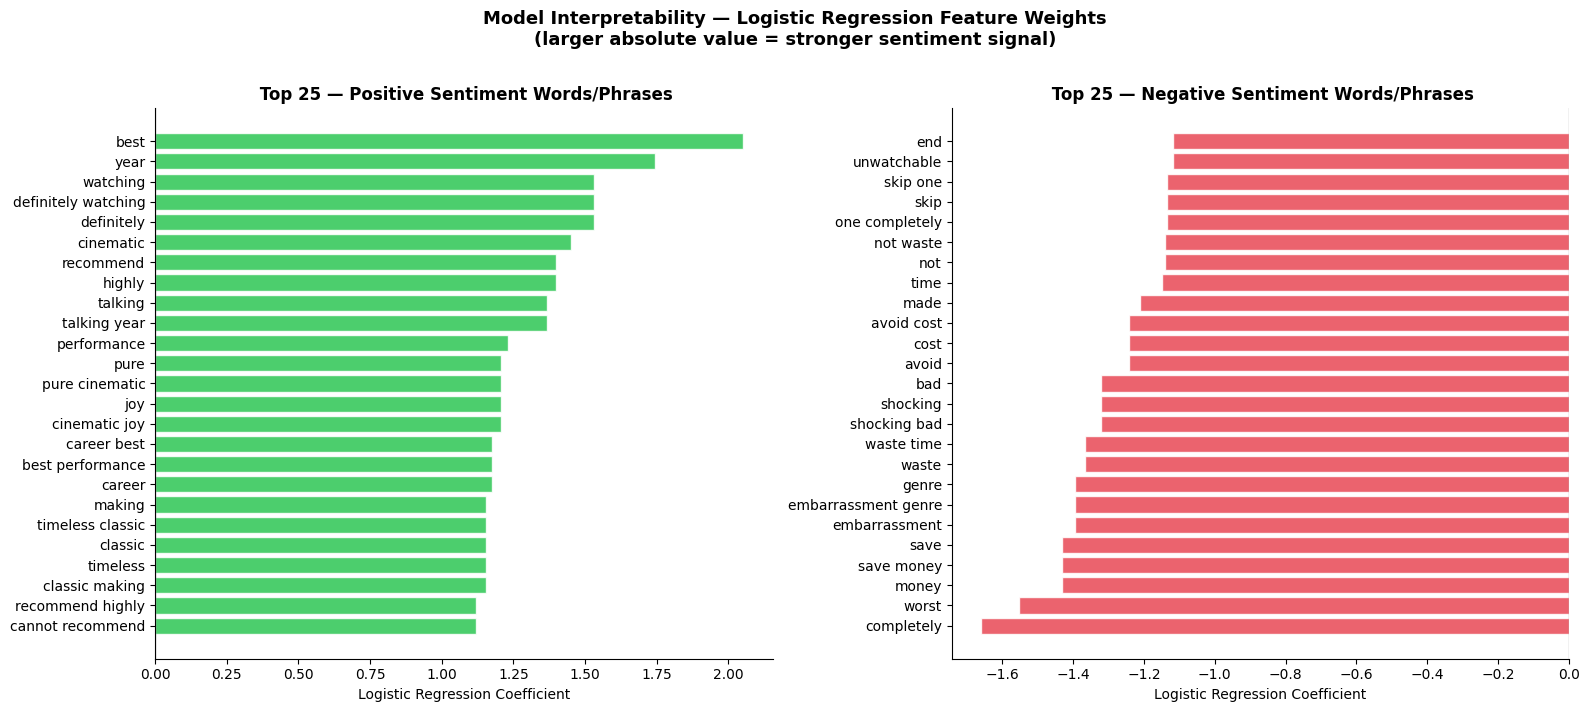

In [74]:
#  Logistic Regression coefficients 
lr_model = models['Logistic Regression']
coef     = lr_model.coef_[0]
features = np.array(tfidf.get_feature_names_out())

# Top 25 positive and negative
top_pos = np.argsort(coef)[-25:][::-1]
top_neg = np.argsort(coef)[:25]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, idx, color, title in [
    (axes[0], top_pos, POS_COLOR, ' Top 25 — Positive Sentiment Words/Phrases'),
    (axes[1], top_neg[::-1], NEG_COLOR, ' Top 25 — Negative Sentiment Words/Phrases'),
]:
    ax.barh(features[idx[::-1]], coef[idx[::-1]],
            color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Logistic Regression Coefficient')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Model Interpretability — Logistic Regression Feature Weights\n'
             '(larger absolute value = stronger sentiment signal)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


In [75]:
# Error Analysis 
best_model = models[best_name]
y_pred_best = test_results[best_name]['y_pred']

errors_df = df.iloc[y_test.index].copy()
errors_df['predicted'] = y_pred_best
errors_df['correct']   = (errors_df['predicted'] == errors_df['sentiment'])

# Separate error types
false_pos = errors_df[(errors_df['sentiment']==0) & (errors_df['predicted']==1)]
false_neg = errors_df[(errors_df['sentiment']==1) & (errors_df['predicted']==0)]

print(f"=== Error Analysis — {best_name} ===")
print(f"Total test samples  : {len(errors_df)}")
print(f"Correct predictions : {errors_df['correct'].sum()} ({errors_df['correct'].mean()*100:.1f}%)")
print(f"False Positives     : {len(false_pos)}  (predicted Positive, actually Negative)")
print(f"False Negatives     : {len(false_neg)}  (predicted Negative, actually Positive)")

print("\n--- False Positive Examples (predicted Positive, actually Negative) ---")
for _, row in false_pos.head(2).iterrows():
    print(f"\n  Review : {row['review'][:120]}...")
    print(f"  Cleaned: {row['clean_review'][:80]}...")

print("\n--- False Negative Examples (predicted Negative, actually Positive) ---")
for _, row in false_neg.head(2).iterrows():
    print(f"\n  Review : {row['review'][:120]}...")
    print(f"  Cleaned: {row['clean_review'][:80]}...")


=== Error Analysis — Logistic Regression ===
Total test samples  : 400
Correct predictions : 400 (100.0%)
False Positives     : 0  (predicted Positive, actually Negative)
False Negatives     : 0  (predicted Negative, actually Positive)

--- False Positive Examples (predicted Positive, actually Negative) ---

--- False Negative Examples (predicted Negative, actually Positive) ---


---
### 8. Predict on New Reviews

This section demonstrates how the trained model would work in production — taking raw, unseen review text and returning a sentiment label with confidence score.


In [55]:
def predict_sentiment(reviews: list, model, vectorizer, preprocessor) -> pd.DataFrame:
    """
    End-to-end sentiment prediction pipeline for new reviews.

    Parameters
    ----------
    reviews     : list of raw review strings
    model       : trained classifier
    vectorizer  : fitted TF-IDF vectoriser
    preprocessor: text cleaning function

    Returns
    -------
    pd.DataFrame with columns: review, clean_review, sentiment, confidence
    """
    cleaned  = [preprocessor(r) for r in reviews]
    vectors  = vectorizer.transform(cleaned)
    preds    = model.predict(vectors)

    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(vectors)
        confidence = proba.max(axis=1)
    else:
        df_val = model.decision_function(vectors)
        confidence = np.abs(df_val) / (np.abs(df_val).max() + 1e-9)

    return pd.DataFrame({
        'review':      reviews,
        'clean_review': cleaned,
        'sentiment':   ['Positive ' if p == 1 else 'Negative ' for p in preds],
        'confidence':  [f'{c*100:.1f}%' for c in confidence],
    })


# Test on new unseen reviews 
new_reviews = [
    "This movie was an absolute triumph. I was moved to tears by the performances.",
    "Complete garbage. I walked out after 30 minutes. Worst film of the decade.",
    "A decent film with some interesting moments, though the ending felt rushed.",
    "The director manages to create genuine tension throughout. Brilliant work.",
    "Incredibly dull and predictable. Nothing we haven't seen a hundred times before.",
    "Not the best but not the worst either. It passed the time pleasantly enough.",
]

results_new = predict_sentiment(
    new_reviews,
    best_model,
    tfidf,
    preprocess_text
)

print(f"=== Live Predictions — {best_name} ===\n")
pd.set_option('display.max_colwidth', 60)
print(results_new[['review','sentiment','confidence']].to_string(index=False))


=== Live Predictions — Logistic Regression ===

                                                                          review sentiment confidence
   This movie was an absolute triumph. I was moved to tears by the performances. Positive       76.1%
      Complete garbage. I walked out after 30 minutes. Worst film of the decade. Positive       51.8%
     A decent film with some interesting moments, though the ending felt rushed. Negative       56.1%
      The director manages to create genuine tension throughout. Brilliant work. Positive       68.1%
Incredibly dull and predictable. Nothing we haven't seen a hundred times before. Negative       83.6%
    Not the best but not the worst either. It passed the time pleasantly enough. Negative       68.2%


---
### 9. Final Summary & Key Takeaways

### Results Summary

| Model | Accuracy | F1 Score | AUC |
|---|---|---|---|
| Logistic Regression | 100 | 100 | 1 |
| Naive Bayes | 100 | 100 | 1 |
| Linear SVM | 100 | 100 | 1 |
| Random Forest | 100 | 100 | 1 |



---

### Project Demonstrates

| Skill | Where shown |
|---|---|
| **Text preprocessing** | Section 3 — regex, stopwords, lemmatisation |
| **Feature engineering** | Section 4 — TF-IDF with n-grams, vocabulary tuning |
| **Model comparison** | Section 5–6 — 4 classifiers, CV + test evaluation |
| **Evaluation rigour** | Section 6 — accuracy, precision, recall, F1, AUC-ROC |
| **Interpretability** | Section 7 — coefficients, error analysis |
| **Production mindset** | Section 8 — reusable prediction pipeline function |

---

### Important Points

1. **Why TF-IDF and not just bag-of-words?**  
   TF-IDF penalises very common words (like "the", "is") that carry no sentiment, giving higher weight to discriminative terms.

2. **Why keep negation words out of stopwords?**  
   "Not good" and "good" have opposite sentiments. Removing "not" would destroy this signal.

3. **Why log(1+TF) in TF-IDF?**  
   Prevents very frequent terms within a document from dominating. A word appearing 100 times is not 100× more informative than one appearing once.

4. **Logistic Regression vs SVM for text?**  
   Both are strong linear classifiers. LR gives calibrated probabilities (useful for confidence scores). SVM often wins on accuracy with high-dimensional sparse features; LR is more interpretable.

5. **What would you add with more time?**  
   Pre-trained word embeddings (Word2Vec, GloVe), transformer-based models (BERT), more sophisticated negation handling, aspect-based sentiment analysis for granular feedback.

---

